# Task-2 : Customer Segmentation using K-Means Clustering

#### 1. Understanding the Problem

The goal of this project is to group customers into distinct segments based on their purchasing behavior. By understanding these segments, businesses can target their marketing efforts more effectively, identify high-value customers, and improve overall retention.

The key features we will analyze include age, annual income, purchase amount, purchase frequency, region, and loyalty score. This is an unsupervised machine learning problem where we will use the K-Means clustering algorithm.

#### 2. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans

# Load the dataset
df = pd.read_csv('Customer Purchasing Behaviors.csv')

# Display the first few rows to understand the structure
df.head()

,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency
0,1,25,45000,200,4.5,North,12
1,2,34,55000,350,7.0,South,18
2,3,45,65000,500,8.0,West,22
3,4,22,30000,150,3.0,East,10
4,5,29,47000,220,4.8,North,13


#### 3. Basic Data Checks

In [2]:
# Check the shape of the dataset
print("Dataset Shape:", df.shape)

# Check data types and basic info
print("\nData Types and Info:")
df.info()

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Handle missing values by dropping them (if any exist)
df.dropna(inplace=True)

# Check for and remove duplicate rows
duplicates = df.duplicated().sum()
print(f"\nFound {duplicates} duplicate rows. Removing them...")
df.drop_duplicates(inplace=True)

print("Cleaned Dataset Shape:", df.shape)

Dataset Shape: (238, 7)

Data Types and Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             238 non-null    int64  
 1   age                 238 non-null    int64  
 2   annual_income       238 non-null    int64  
 3   purchase_amount     238 non-null    int64  
 4   loyalty_score       238 non-null    float64
 5   region              238 non-null    object 
 6   purchase_frequency  238 non-null    int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 13.1+ KB

Missing Values:
user_id               0
age                   0
annual_income         0
purchase_amount       0
loyalty_score         0
region                0
purchase_frequency    0
dtype: int64

Found 0 duplicate rows. Removing them...
Cleaned Dataset Shape: (238, 7)


#### 4. Exploratory Data Analysis (EDA)

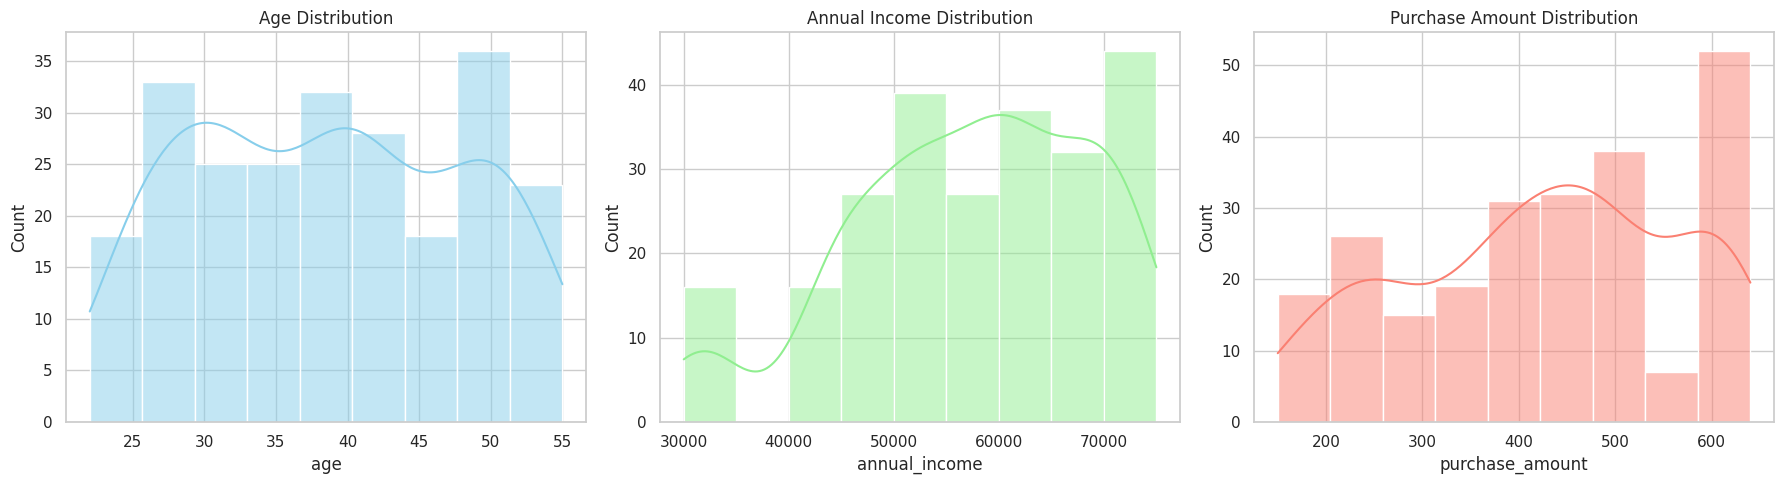

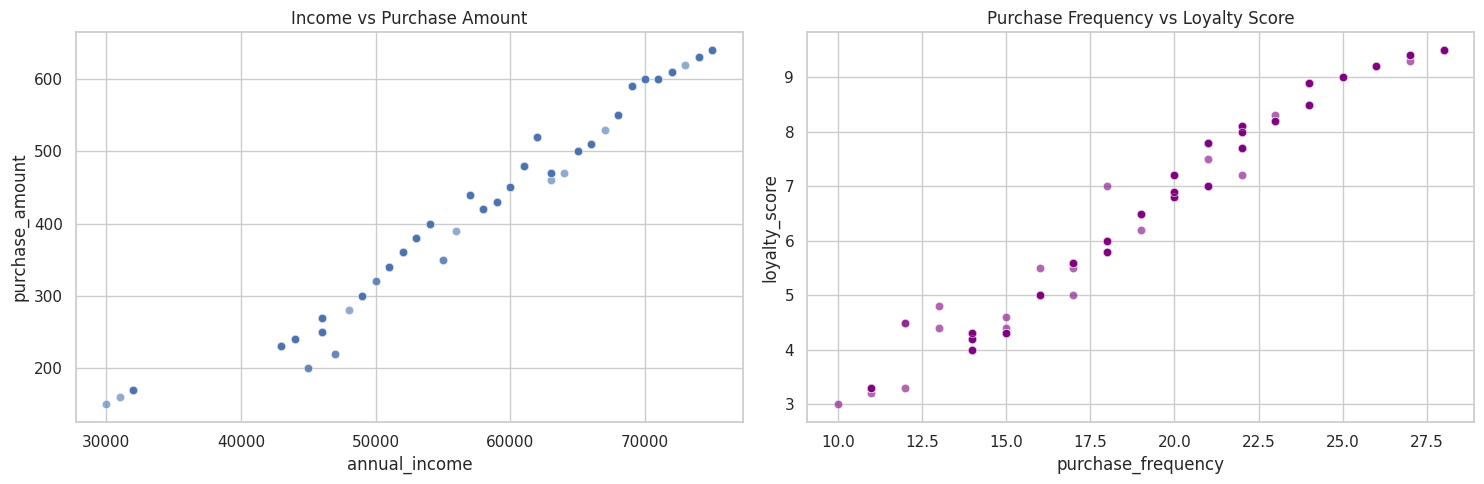

In [3]:
# Set up the visualization style
sns.set_theme(style="whitegrid")

# Univariate Analysis: Looking at individual distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Age Distribution')

sns.histplot(df['annual_income'], kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Annual Income Distribution')

sns.histplot(df['purchase_amount'], kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Purchase Amount Distribution')

plt.tight_layout()
plt.show()

# Bivariate Analysis: Looking at relationships between two variables
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Income vs Purchase Amount
sns.scatterplot(data=df, x='annual_income', y='purchase_amount', alpha=0.6, ax=axes[0])
axes[0].set_title('Income vs Purchase Amount')

# Purchase Frequency vs Loyalty Score
sns.scatterplot(data=df, x='purchase_frequency', y='loyalty_score', alpha=0.6, ax=axes[1], color='purple')
axes[1].set_title('Purchase Frequency vs Loyalty Score')

plt.tight_layout()
plt.show()

### Insights from Exploratory Data Analysis (EDA)

**Univariate Analysis:**
*   **Age Distribution:** The histogram for age shows the distribution of customer ages, indicating a spread across different age groups. (A more specific observation would require viewing the plot, e.g., if it's skewed or concentrated in certain age brackets).
*   **Annual Income Distribution:** The annual income distribution helps understand the income levels of the customer base. (Similar to age, specific observations depend on the visual, e.g., presence of high-income outliers or a predominantly middle-income group).
*   **Purchase Amount Distribution:** This histogram shows the frequency of different purchase amounts, which can reveal common spending habits or high-value transaction occurrences.

**Bivariate Analysis:**
*   **Income vs Purchase Amount:** The scatter plot likely illustrates a relationship between a customer's income and their spending. Often, a positive correlation is observed, meaning higher incomes might correspond to higher purchase amounts.
*   **Purchase Frequency vs Loyalty Score:** This plot visually represents how often customers purchase relative to their loyalty. A positive correlation is generally expected here, where more frequent purchases could indicate higher loyalty.

These initial explorations provide a foundational understanding of the dataset's characteristics and potential relationships between customer attributes, which is valuable for subsequent modeling.

#### 5. Data Preprocessing

Machine learning models require numerical input and generally perform better when features are on a similar scale. We will encode the categorical 'region' column and standardize our numerical features.

In [4]:
# Encode the categorical 'region' column
encoder = LabelEncoder()
if 'region' in df.columns:
    df['region_encoded'] = encoder.fit_transform(df['region'])

# Initialize the StandardScaler
scaler = StandardScaler()

# We will scale all numeric columns so they have a mean of 0 and variance of 1
numeric_cols = df.select_dtypes(include=[np.number]).columns
df_scaled = pd.DataFrame(scaler.fit_transform(df[numeric_cols]), columns=numeric_cols)

df_scaled.head()

,user_id,age,annual_income,purchase_amount,loyalty_score,purchase_frequency,region_encoded
0,-1.724789,-1.465632,-1.090306,-1.614441,-1.210582,-1.712679,-1.092272
1,-1.710233,-0.501151,-0.211563,-0.541153,0.108642,-0.394950,0.063109
2,-1.695678,0.677658,0.667180,0.532134,0.636332,0.483536,1.218490
3,-1.681123,-1.787125,-2.408420,-1.972203,-2.002117,-2.151922,-2.247652
4,-1.666568,-1.036974,-0.914557,-1.471336,-1.052275,-1.493057,-1.092272


#### 6. Feature Selection

We do not necessarily need all columns for clustering. Based on the project requirements, we will isolate the features that most directly represent purchasing behavior.

In [5]:
# Select the relevant features for the K-Means algorithm
selected_features = [
    'annual_income',
    'purchase_amount',
    'purchase_frequency',
    'loyalty_score'
]

X = df_scaled[selected_features]

X.head()

,annual_income,purchase_amount,purchase_frequency,loyalty_score
0,-1.090306,-1.614441,-1.712679,-1.210582
1,-0.211563,-0.541153,-0.394950,0.108642
2,0.667180,0.532134,0.483536,0.636332
3,-2.408420,-1.972203,-2.151922,-2.002117
4,-0.914557,-1.471336,-1.493057,-1.052275


#### 7. Apply K-Means Clustering

To find the optimal number of clusters (K), we will use the Elbow Method. Once we determine the best K, we will fit the final model and assign the cluster labels back to our original dataset.

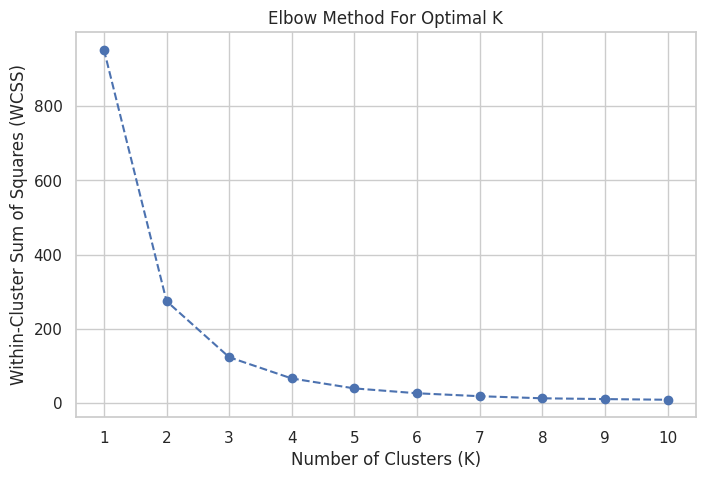

,annual_income,purchase_amount,purchase_frequency,loyalty_score,Customer_Segment
0,45000,200,12,4.5,2
1,55000,350,18,7.0,1
2,65000,500,22,8.0,3
3,30000,150,10,3.0,2
4,47000,220,13,4.8,2
5,61000,480,21,7.8,3
6,54000,400,19,6.5,1
7,43000,230,14,4.2,2
8,70000,600,25,9.0,0
9,50000,320,17,5.5,1


In [6]:
# Use the Elbow method to find the optimal number of clusters
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(K_range)
plt.show()

# Assuming the elbow indicates 4 clusters is optimal based on the plot
optimal_k = 4

# Fit the final K-Means model
final_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)

# Assign the cluster labels to our original dataframe
df['Customer_Segment'] = final_kmeans.fit_predict(X)

# View the final segmented dataframe
df[['annual_income', 'purchase_amount', 'purchase_frequency', 'loyalty_score', 'Customer_Segment']].head(10)

### K-Means Clustering Results:

**Elbow Method for Optimal K:**
The Elbow Method plot displays the Within-Cluster Sum of Squares (WCSS) for different numbers of clusters (K). The WCSS generally decreases as K increases, but the rate of decrease typically slows down significantly at a certain point, forming an 'elbow'. In this case, based on the plot, **K=4** was chosen as the optimal number of clusters, as this is where the curve visibly bends, suggesting a good balance between minimizing WCSS and having a reasonable number of clusters.

**Customer Segment Assignment:**
After identifying K=4 as optimal, the K-Means algorithm was applied to the selected features. Each customer in the dataset has now been assigned a `Customer_Segment` label (0, 1, 2, or 3). This segmentation successfully groups customers with similar purchasing behaviors into distinct clusters, providing a basis for targeted marketing and customer management strategies. Further analysis of the centroids of these clusters would reveal the defining characteristics of each segment.

In [7]:
import pickle

# Bundle the final model, the scaler, and the exact column structures
saved_data = {
    'model': final_kmeans,                 # K-Means model (k=4)
    'scaler': scaler,                      # fitted StandardScaler
    'numeric_cols': numeric_cols,          # The 7 columns the scaler expects
    'selected_features': selected_features # The 4 columns the model expects
}

# Save as a single pickle file
with open('customer_segmentation_pipeline.pkl', 'wb') as f:
    pickle.dump(saved_data, f)

print("Model and Scaler successfully bundled into customer_segmentation_pipeline.pkl!")

Model and Scaler successfully bundled into customer_segmentation_pipeline.pkl!
